# Iron Kaggle — Store Sales Prediction
**Goal:** Predict daily store sales using the training dataset.  
**Target:** `sales` (regression)  
**Metric:** R² Score

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')


---
## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv('training.csv')
print('Shape:', df.shape)
df.head()

Shape: (640840, 10)


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [4]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [5]:
# Check unique values for categorical columns
print('state_holiday unique values:', df['state_holiday'].unique())
print('open value counts:\n', df['open'].value_counts())
print('school_holiday value counts:\n', df['school_holiday'].value_counts())
print('promotion value counts:\n', df['promotion'].value_counts())

state_holiday unique values: ['0' 'a' 'c' 'b']
open value counts:
 open
1    532016
0    108824
Name: count, dtype: int64
school_holiday value counts:
 school_holiday
0    526468
1    114372
Name: count, dtype: int64
promotion value counts:
 promotion
0    396220
1    244620
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis (EDA)

In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


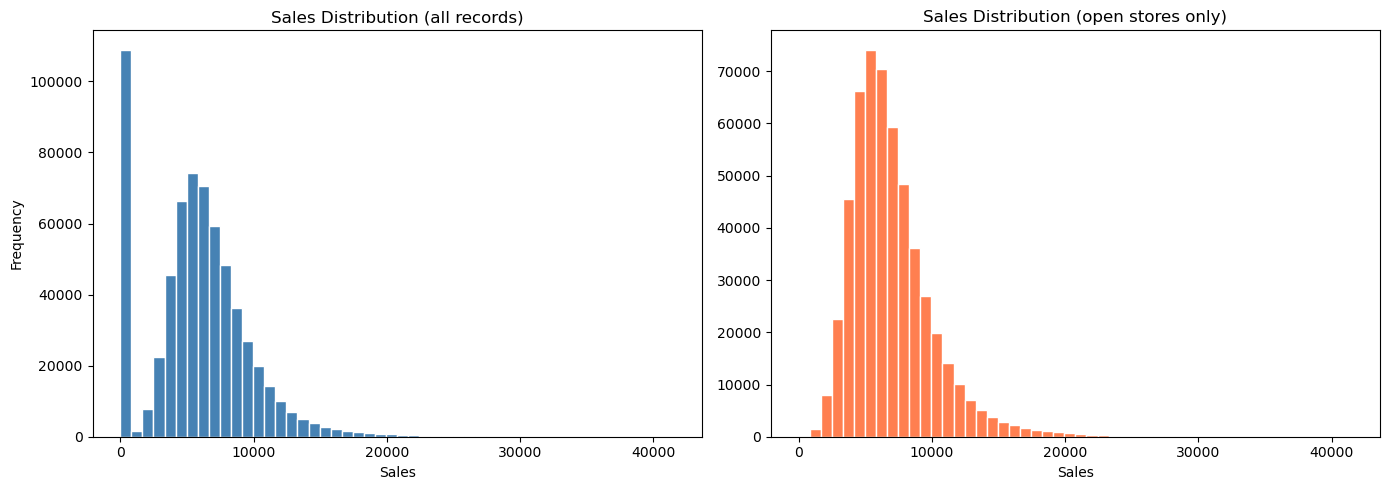

Records where store is closed (sales=0): 108824 (17.0%)


In [7]:
# Sales distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (all records)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Sales when store is open only (more meaningful)
open_sales = df[df['open'] == 1]['sales']
axes[1].hist(open_sales, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sales Distribution (open stores only)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()

print(f'Records where store is closed (sales=0): {(df["open"]==0).sum()} ({(df["open"]==0).mean()*100:.1f}%)')

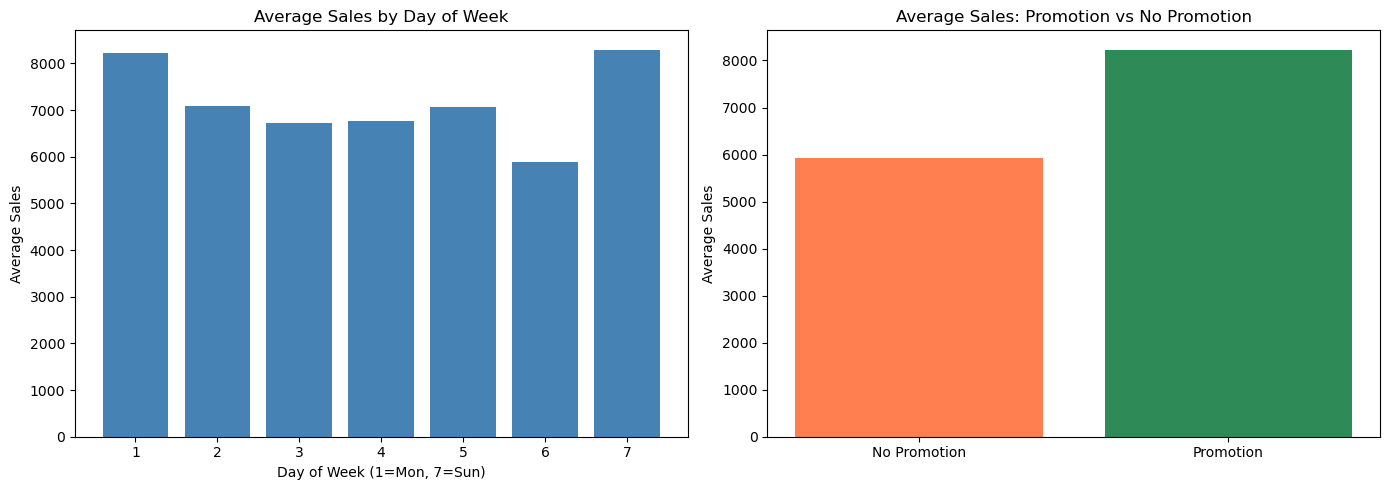

In [8]:
# Average sales by day of week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_sales = df[df['open']==1].groupby('day_of_week')['sales'].mean()
axes[0].bar(day_sales.index, day_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Day of Week')
axes[0].set_xlabel('Day of Week (1=Mon, 7=Sun)')
axes[0].set_ylabel('Average Sales')

# Sales with/without promotion
promo_sales = df[df['open']==1].groupby('promotion')['sales'].mean()
axes[1].bar(['No Promotion', 'Promotion'], promo_sales.values, color=['coral', 'seagreen'])
axes[1].set_title('Average Sales: Promotion vs No Promotion')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

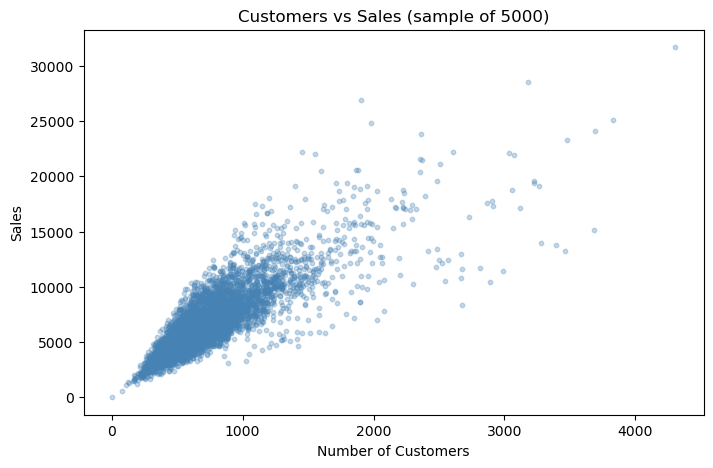

Correlation between nb_customers_on_day and sales: 0.8237


In [9]:
# Correlation between nb_customers and sales
open_df = df[df['open'] == 1]
plt.figure(figsize=(8, 5))
plt.scatter(open_df['nb_customers_on_day'].sample(5000, random_state=42),
            open_df['sales'].sample(5000, random_state=42),
            alpha=0.3, color='steelblue', s=10)
plt.title('Customers vs Sales (sample of 5000)')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.show()

corr = open_df[['nb_customers_on_day', 'sales']].corr()
print('Correlation between nb_customers_on_day and sales:', corr.loc['nb_customers_on_day', 'sales'].round(4))

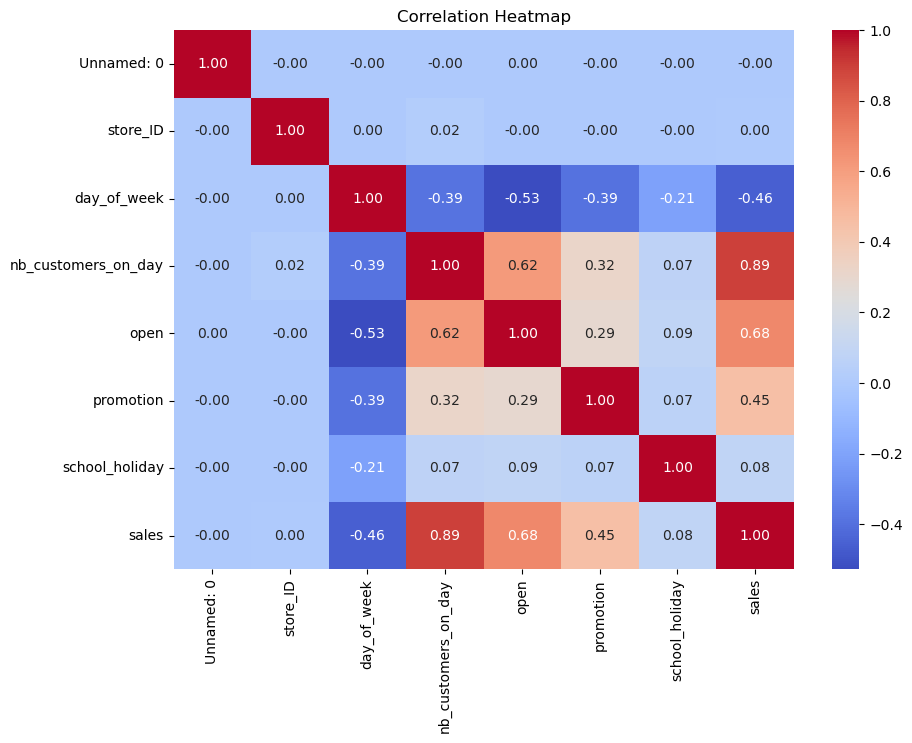

In [10]:
# Correlation heatmap (numeric columns)
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observations:**
- ~17% of records are for closed stores (sales = 0). These are trivial and should be filtered out.
- `nb_customers_on_day` has a very strong positive correlation with `sales`.
- Promotions noticeably increase average sales.
- Monday and Sunday show different sales patterns.

---
## 4. Data Cleaning

In [11]:
# Filter: keep only open store days (closed stores have sales=0, not useful for prediction)
df_clean = df[df['open'] == 1].copy()
print(f'Rows before filtering: {len(df)}')
print(f'Rows after filtering (open only): {len(df_clean)}')

# Drop the index column and 'open' (all 1s now)
df_clean.drop(columns=['Unnamed: 0', 'open'], inplace=True)
print('Dropped: Unnamed: 0, open')
df_clean.head()

Rows before filtering: 640840
Rows after filtering (open only): 532016
Dropped: Unnamed: 0, open


,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,sales
0,366,4,2013-04-18,517,0,0,0,4422
1,394,6,2015-04-11,694,0,0,0,8297
2,807,4,2013-08-29,970,1,0,0,9729
3,802,2,2013-05-28,473,1,0,0,6513
4,726,4,2013-10-10,1068,1,0,0,10882


In [12]:
# Confirm no missing values remain
print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


---
## 5. Feature Engineering

In [13]:
# Parse date column and extract time features
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean['month']        = df_clean['date'].dt.month
df_clean['year']         = df_clean['date'].dt.year
df_clean['week']         = df_clean['date'].dt.isocalendar().week.astype(int)
df_clean['day_of_month'] = df_clean['date'].dt.day
df_clean['is_weekend']   = (df_clean['day_of_week'] >= 6).astype(int)

print('New date features added: month, year, week, day_of_month, is_weekend')
df_clean[['date','month','year','week','day_of_month','is_weekend']].head()

New date features added: month, year, week, day_of_month, is_weekend


,date,month,year,week,day_of_month,is_weekend
0,2013-04-18,4,2013,16,18,0
1,2015-04-11,4,2015,15,11,1
2,2013-08-29,8,2013,35,29,0
3,2013-05-28,5,2013,22,28,0
4,2013-10-10,10,2013,41,10,0


In [14]:
# Store-level aggregation features (mean, median, std of sales per store)
# These capture the baseline performance of each store
store_stats = df_clean.groupby('store_ID')['sales'].agg(['mean','median','std'])
store_stats.columns = ['store_mean_sales', 'store_med_sales', 'store_std_sales']
store_stats = store_stats.reset_index()

df_clean = df_clean.merge(store_stats, on='store_ID', how='left')
print('Store-level features added: store_mean_sales, store_med_sales, store_std_sales')
df_clean[['store_ID','store_mean_sales','store_med_sales','store_std_sales']].head()

Store-level features added: store_mean_sales, store_med_sales, store_std_sales


,store_ID,store_mean_sales,store_med_sales,store_std_sales
0,366,6206.869739,6011.0,2217.926336
1,394,8404.937378,8207.0,1997.824459
2,807,9824.892713,9773.5,1678.089636
3,802,6754.329060,6561.0,1652.507819
4,726,11052.675620,10497.5,3809.830786


---
## 6. Encoding Categorical Variables

In [15]:
# Encode state_holiday: '0'=no holiday, 'a'=public, 'b'=Easter, 'c'=Christmas
le = LabelEncoder()
df_clean['state_holiday_enc'] = le.fit_transform(df_clean['state_holiday'])

print('state_holiday encoding mapping:')
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {label!r} -> {code}')

state_holiday encoding mapping:
  '0' -> 0
  'a' -> 1
  'b' -> 2
  'c' -> 3


---
## 7. Prepare Features and Target

In [16]:
FEATURES = [
    'store_ID',
    'day_of_week',
    'nb_customers_on_day',
    'promotion',
    'state_holiday_enc',
    'school_holiday',
    'month',
    'year',
    'week',
    'day_of_month',
    'is_weekend',
    'store_mean_sales',
    'store_med_sales',
    'store_std_sales',
]

TARGET = 'sales'

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Features used: {FEATURES}')

Feature matrix shape: (532016, 14)
Target shape:         (532016,)
Features used: ['store_ID', 'day_of_week', 'nb_customers_on_day', 'promotion', 'state_holiday_enc', 'school_holiday', 'month', 'year', 'week', 'day_of_month', 'is_weekend', 'store_mean_sales', 'store_med_sales', 'store_std_sales']


---
## 8. Train / Validation Split

We use **training.csv** only for model development, with a **time-based 80% / 20% split**:
- **Train (80%)**: model learns patterns from historical data
- **Validation (20%)**: used to compare models and check generalisation

`real_data.csv` is kept completely separate and is used only at the end for final prediction.


In [17]:
# Sort by date for a realistic temporal split
df_sorted = df_clean.sort_values('date')
X_sorted  = X.loc[df_sorted.index]
y_sorted  = y.loc[df_sorted.index]

train_end = int(len(df_sorted) * 0.80)

X_train = X_sorted.iloc[:train_end]
X_val   = X_sorted.iloc[train_end:]

y_train = y_sorted.iloc[:train_end]
y_val   = y_sorted.iloc[train_end:]

print(f'Training set   : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Validation set : {len(X_val):,} rows  ({len(X_val)/len(X)*100:.0f}%)')
print()
print(f'Train dates : {df_sorted["date"].iloc[0].date()} → {df_sorted["date"].iloc[train_end-1].date()}')
print(f'Val dates   : {df_sorted["date"].iloc[train_end].date()} → {df_sorted["date"].iloc[-1].date()}')


Training set   : 425,612 rows  (80%)
Validation set : 106,404 rows  (20%)

Train dates : 2013-01-01 → 2015-01-30
Val dates   : 2015-01-30 → 2015-07-31


---
## 9. Baseline Model — Linear Regression

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

lr_train_r2 = r2_score(y_train, lr.predict(X_train_sc))
lr_val_r2   = r2_score(y_val,   lr.predict(X_val_sc))

print('Linear Regression')
print(f'  Train R²      : {lr_train_r2:.4f}  ({lr_train_r2*100:.2f}%)')
print(f'  Validation R² : {lr_val_r2:.4f}  ({lr_val_r2*100:.2f}%)')


Linear Regression
  Train R²      : 0.8230  (82.30%)
  Validation R² : 0.8221  (82.21%)


---
## 10. Model 2 — Random Forest Regressor

In [19]:
# Use a sample for faster training during exploration
sample_frac = 0.20  # increase to 1.0 for final training
X_tr_s = X_train.sample(frac=sample_frac, random_state=42)
y_tr_s = y_train.loc[X_tr_s.index]

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr_s, y_tr_s)

rf_train_r2 = r2_score(y_tr_s, rf.predict(X_tr_s))
rf_val_r2   = r2_score(y_val,  rf.predict(X_val))

print('Random Forest Regressor')
print(f'  Train R²      : {rf_train_r2:.4f}  ({rf_train_r2*100:.2f}%)')
print(f'  Validation R² : {rf_val_r2:.4f}  ({rf_val_r2*100:.2f}%)')


Random Forest Regressor
  Train R²      : 0.9691  (96.91%)
  Validation R² : 0.9186  (91.86%)


---
## 11. Model 3 — Gradient Boosting Regressor (Best Model)

In [20]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_tr_s, y_tr_s)  # same sample as RF for fair comparison

gb_train_r2 = r2_score(y_tr_s, gb.predict(X_tr_s))
gb_val_r2   = r2_score(y_val,  gb.predict(X_val))

print('Gradient Boosting Regressor')
print(f'  Train R²      : {gb_train_r2:.4f}  ({gb_train_r2*100:.2f}%)')
print(f'  Validation R² : {gb_val_r2:.4f}  ({gb_val_r2*100:.2f}%)')


Gradient Boosting Regressor
  Train R²      : 0.9448  (94.48%)
  Validation R² : 0.9132  (91.32%)


---
## 12. Model 4 — XGBoost Regressor

XGBoost (Extreme Gradient Boosting) improves on standard Gradient Boosting by being:
- **Faster** — parallelised tree building
- **More regularised** — `reg_alpha` (L1) and `reg_lambda` (L2) penalties reduce overfitting
- **Better with missing data** — handles it natively
- **More tunable** — `colsample_bytree` randomly selects features per tree, like Random Forest, reducing variance

In [35]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.06,
    subsample=0.8,
    colsample_bytree=0.8,   # use 80% of features per tree — reduces overfitting
    reg_alpha=0.1,           # L1 regularisation
    reg_lambda=1.0,          # L2 regularisation
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_tr_s, y_tr_s,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_train_r2 = r2_score(y_tr_s, xgb.predict(X_tr_s))
xgb_val_r2   = r2_score(y_val,  xgb.predict(X_val))

print('XGBoost Regressor')
print(f'  Train R²      : {xgb_train_r2:.4f}  ({xgb_train_r2*100:.2f}%)')
print(f'  Validation R² : {xgb_val_r2:.4f}  ({xgb_val_r2*100:.2f}%)')
print(f'  Train-Val Gap : {xgb_train_r2 - xgb_val_r2:.4f}')


XGBoost Regressor
  Train R²      : 0.9537  (95.37%)
  Validation R² : 0.9189  (91.89%)
  Train-Val Gap : 0.0348


---
## 13. Model Comparison — All 4 Models

In [36]:
results = pd.DataFrame({
    'Model'        : ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Train R²'     : [lr_train_r2,  rf_train_r2,  gb_train_r2,  xgb_train_r2],
    'Val R²'       : [lr_val_r2,    rf_val_r2,    gb_val_r2,    xgb_val_r2],
    'Train-Val Gap': [lr_train_r2  - lr_val_r2,
                      rf_train_r2  - rf_val_r2,
                      gb_train_r2  - gb_val_r2,
                      xgb_train_r2 - xgb_val_r2],
})
results = results.sort_values('Val R²', ascending=False).reset_index(drop=True)
results.round(4)


,Model,Train R²,Val R²,Train-Val Gap
0,XGBoost,0.9537,0.9189,0.0348
1,Random Forest,0.9691,0.9186,0.0505
2,Gradient Boosting,0.9448,0.9132,0.0316
3,Linear Regression,0.8230,0.8221,0.0009


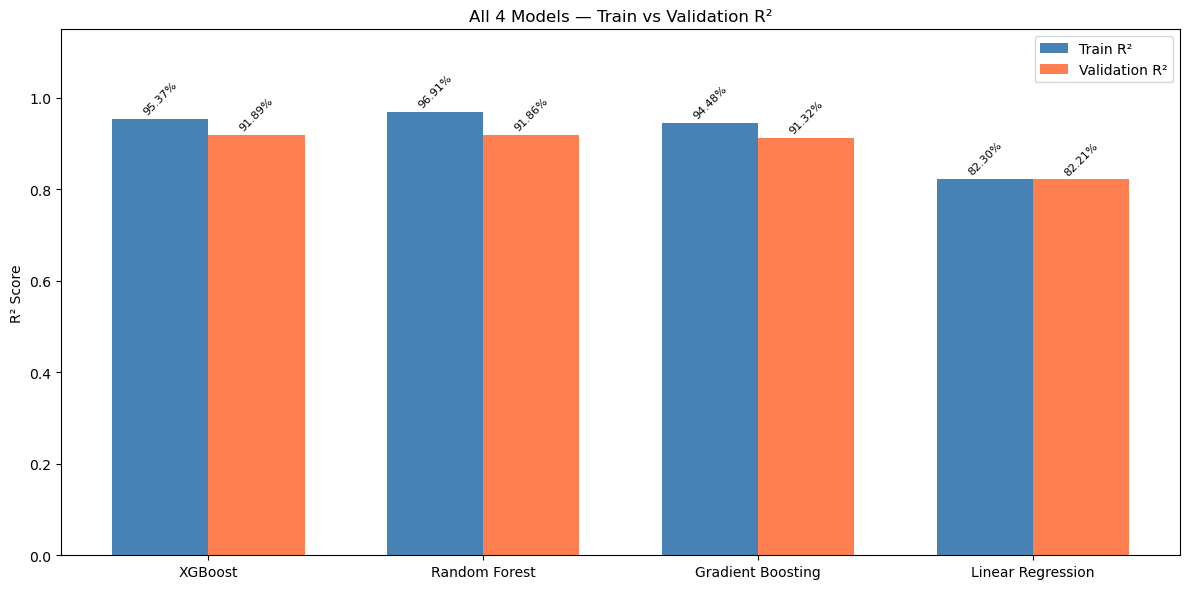

In [37]:
# Bar chart: Train vs Validation R² for all 4 models
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['Train R²'], width, label='Train R²',      color='steelblue')
bars2 = ax.bar(x + width/2, results['Val R²'],   width, label='Validation R²', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('R² Score')
ax.set_title('All 4 Models — Train vs Validation R²')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()


---
## 14. Feature Importance — Gradient Boosting vs XGBoost

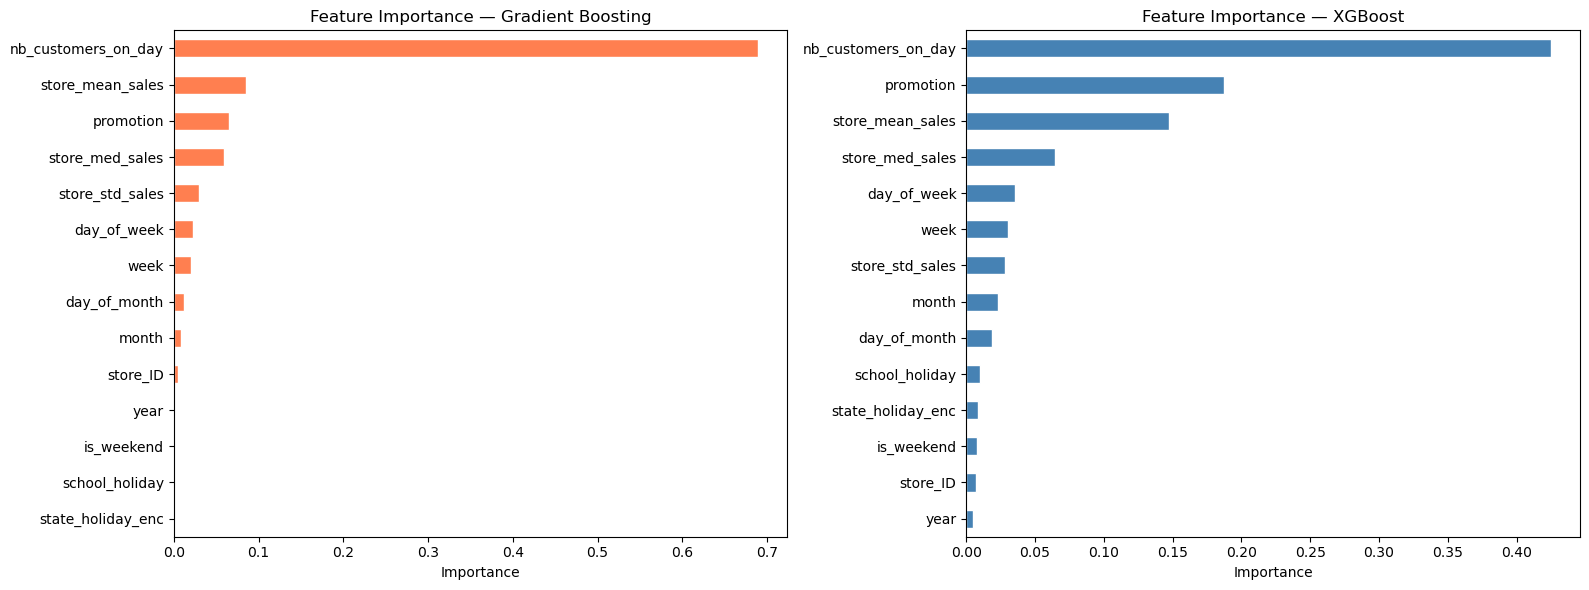


Gradient Boosting importances:
nb_customers_on_day    0.689424
store_mean_sales       0.085594
promotion              0.064837
store_med_sales        0.059323
store_std_sales        0.029991
day_of_week            0.023229
week                   0.019808
day_of_month           0.012009
month                  0.008078
store_ID               0.005625
year                   0.000785
is_weekend             0.000630
school_holiday         0.000449
state_holiday_enc      0.000216
dtype: float64

XGBoost importances:
nb_customers_on_day    0.424738
promotion              0.187050
store_mean_sales       0.147682
store_med_sales        0.064562
day_of_week            0.035635
week                   0.030527
store_std_sales        0.028322
month                  0.023089
day_of_month           0.018850
school_holiday         0.010010
state_holiday_enc      0.008858
is_weekend             0.008139
store_ID               0.007345
year                   0.005192
dtype: float32


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gradient Boosting
fi_gb = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi_gb.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Feature Importance — Gradient Boosting')
axes[0].set_xlabel('Importance')

# XGBoost
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi_xgb.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('\nGradient Boosting importances:')
print(fi_gb.sort_values(ascending=False))
print('\nXGBoost importances:')
print(fi_xgb.sort_values(ascending=False))

---
## 15. Final Model — Retrain on Full `training.csv`

After comparing models on the 80/20 development split, we keep **XGBoost** as the final model and retrain it on **all rows from `training.csv`** before generating predictions for `real_data.csv`.


In [38]:
# Re-train XGBoost on all available rows from training.csv
X_full = X_sorted.copy()
y_full = y_sorted.copy()

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
final_model.fit(X_full, y_full, verbose=False)
print('Final XGBoost model retrained on 100% of training.csv successfully.')


Final XGBoost model retrained on 100% of training.csv successfully.


---
## 16. Development Metrics — Train and Validation

These metrics are computed on the **development model** (`xgb`) that was trained on the 80% training split and checked on the 20% validation split.

> **Note:** Accuracy and Recall are classification metrics (used for categories like yes/no).  
> For regression (predicting a number like sales), the equivalents are:
> - **R²** → overall fit quality (like accuracy)
> - **MAE** → average error in sales units
> - **MSE** → mean squared error (punishes big mistakes more)
> - **RMSE** → same units as sales, easier to interpret than MSE
> - **Within 10% Accuracy** → % of predictions within 10% of actual value


In [26]:
def get_metrics(model, X, y, label):
    """Calculate all regression metrics for a given split."""
    preds = model.predict(X)
    actuals = np.array(y)

    r2   = r2_score(actuals, preds)
    mae  = mean_absolute_error(actuals, preds)
    mse  = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)

    # Within 10% accuracy: % of predictions within 10% of the actual value
    within_10pct = np.mean(np.abs(preds - actuals) / np.where(actuals == 0, 1, actuals) <= 0.10) * 100

    return {
        'Split'               : label,
        'R²'                  : round(r2, 4),
        'MAE'                 : round(mae, 2),
        'MSE'                 : round(mse, 2),
        'RMSE'                : round(rmse, 2),
        'Within 10% Accuracy' : round(within_10pct, 2),
    }


metrics = pd.DataFrame([
    get_metrics(xgb, X_train, y_train, 'Train'),
    get_metrics(xgb, X_val,   y_val,   'Validation'),
])
metrics.set_index('Split', inplace=True)
metrics


,R²,MAE,MSE,RMSE,Within 10% Accuracy
Split,,,,,
Train,0.9438,522.36,544712.69,738.05,70.79
Validation,0.9134,630.21,812965.06,901.65,64.74


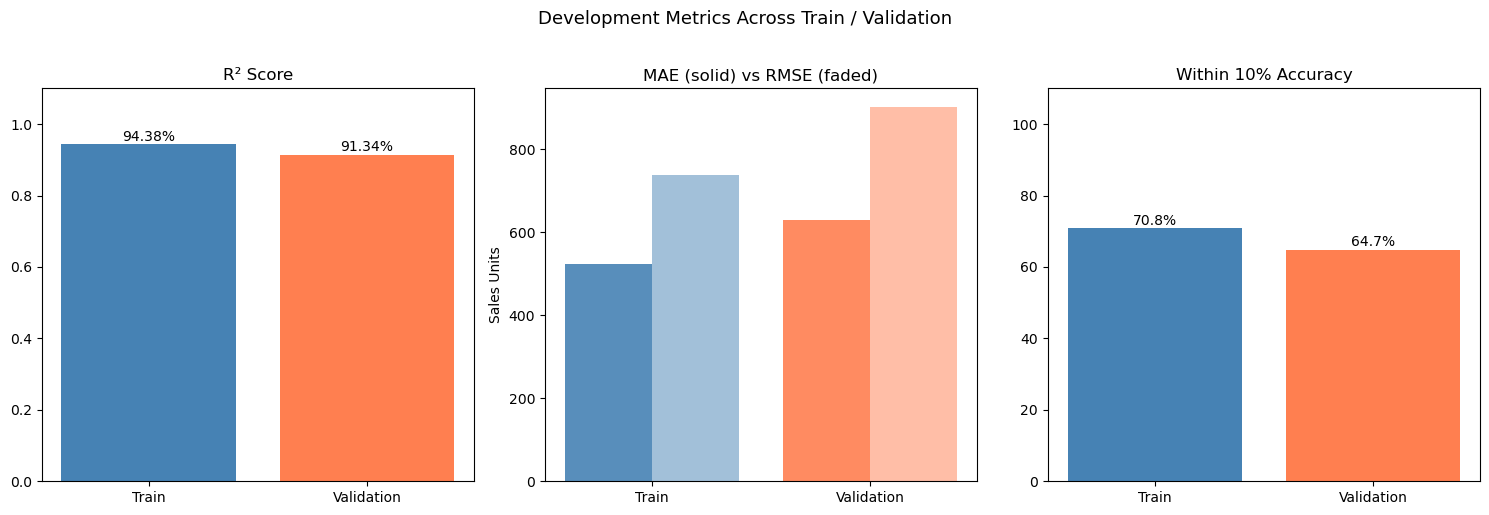

In [39]:
# Visualise development metrics side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = metrics.index.tolist()
colors = ['steelblue', 'coral']

# R²
axes[0].bar(splits, metrics['R²'], color=colors)
axes[0].set_title('R² Score')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(metrics['R²']):
    axes[0].text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=10)

# MAE / RMSE
x = np.arange(len(splits))
axes[1].bar(x - 0.2, metrics['MAE'],  width=0.4, color=colors, label='MAE',  alpha=0.9)
axes[1].bar(x + 0.2, metrics['RMSE'], width=0.4, color=colors, label='RMSE', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(splits)
axes[1].set_title('MAE (solid) vs RMSE (faded)')
axes[1].set_ylabel('Sales Units')

# Within 10% Accuracy
axes[2].bar(splits, metrics['Within 10% Accuracy'], color=colors)
axes[2].set_title('Within 10% Accuracy')
axes[2].set_ylim(0, 110)
for i, v in enumerate(metrics['Within 10% Accuracy']):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Development Metrics Across Train / Validation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 17. Residual Analysis

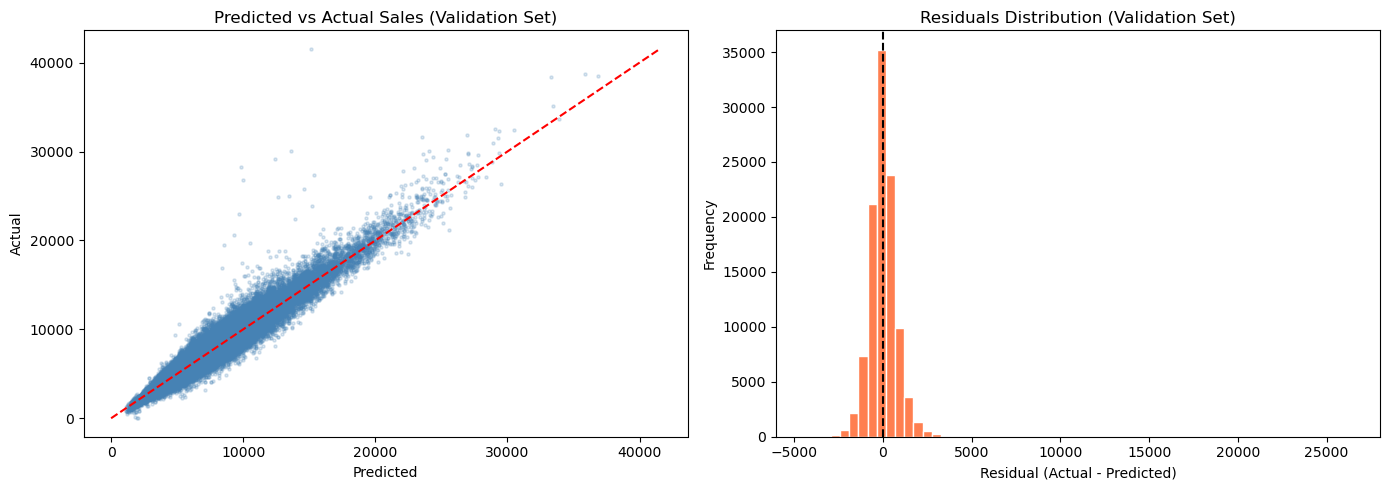

MAE  : 556
RMSE : 774
R²   : 0.9362


In [28]:
val_preds    = final_model.predict(X_val)
residuals    = y_val.values - val_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(val_preds, y_val, alpha=0.2, s=5, color='steelblue')
max_val = max(val_preds.max(), y_val.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[0].set_title('Predicted vs Actual Sales (Validation Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Residuals
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residuals Distribution (Validation Set)')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'MAE  : {mean_absolute_error(y_val, val_preds):,.0f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_val, val_preds)):,.0f}')
print(f'R²   : {r2_score(y_val, val_preds):.4f}')

---
## 18. Generate Predictions on `real_data.csv`

Preprocess `real_data.csv` using the same feature pipeline and run the retrained final model on it.


In [29]:
def preprocess_real(raw_df, store_stats_df, le):
    """
    Preprocess real_data.csv using the same pipeline as training.
    store_stats_df : store_stats computed from training data.
    le             : fitted LabelEncoder for state_holiday.
    """
    df = raw_df.copy()

    # Filter open stores
    df = df[df['open'] == 1].copy()

    # Drop unnecessary columns
    for col in ['index', 'Unnamed: 0', 'open']:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Date features
    df['date']         = pd.to_datetime(df['date'])
    df['month']        = df['date'].dt.month
    df['year']         = df['date'].dt.year
    df['week']         = df['date'].dt.isocalendar().week.astype(int)
    df['day_of_month'] = df['date'].dt.day
    df['is_weekend']   = (df['day_of_week'] >= 6).astype(int)

    # Store-level features from training data
    df = df.merge(store_stats_df, on='store_ID', how='left')

    # Encode state_holiday using the fitted encoder from training data
    state_holiday_map = {label: code for code, label in enumerate(le.classes_)}
    df['state_holiday_enc'] = df['state_holiday'].map(state_holiday_map)

    if df['state_holiday_enc'].isnull().any():
        unseen = sorted(df.loc[df['state_holiday_enc'].isnull(), 'state_holiday'].astype(str).unique())
        raise ValueError(f'Unseen state_holiday values found in real_data.csv: {unseen}')

    df['state_holiday_enc'] = df['state_holiday_enc'].astype(int)
    return df


def find_csv_file(candidates):
    """Return the first matching CSV file, handling different capitalisations."""
    cwd = Path('.')
    existing = {p.name.lower(): p for p in cwd.glob('*.csv')}

    for name in candidates:
        if Path(name).exists():
            return Path(name)
        if name.lower() in existing:
            return existing[name.lower()]

    raise FileNotFoundError(f'None of these files were found: {candidates}')


# Load and preprocess real_data.csv
real_path      = find_csv_file(['real_data.csv', 'REAL_DATA.csv'])
real_df        = pd.read_csv(real_path)
real_processed = preprocess_real(real_df, store_stats, le)

print(f'Loaded inference file         : {real_path.name}')
print(f'real_data rows total          : {len(real_df):,}')
print(f'real_data rows (open stores)  : {len(real_processed):,}')
print('Missing values after preprocessing:')
print(real_processed[FEATURES].isnull().sum())


Loaded inference file         : real_data.csv
real_data rows total          : 71,205
real_data rows (open stores)  : 59,105
Missing values after preprocessing:
store_ID               0
day_of_week            0
nb_customers_on_day    0
promotion              0
state_holiday_enc      0
school_holiday         0
month                  0
year                   0
week                   0
day_of_month           0
is_weekend             0
store_mean_sales       0
store_med_sales        0
store_std_sales        0
dtype: int64


In [ ]:
# Generate predictions
predictions = final_model.predict(real_processed[FEATURES])

# Build output dataframe
#output = real_processed[['store_ID', 'date']].copy()
#output['predicted_sales'] = predictions.astype(int)
output = pd.DataFrame({

    'predicted_sales': predictions.astype(int)
})

# Save to G2.csv
output.to_csv('G2.csv', index=False)

print(f'Predictions saved to G2.csv')
print(f'Total predictions : {len(output):,}')
print(f'Predicted sales — min: {output["predicted_sales"].min():,}  max: {output["predicted_sales"].max():,}  mean: {output["predicted_sales"].mean():,.0f}')
output.head(10)

Predictions saved to G1.csv
Total predictions : 59,105
Predicted sales — min: 962  max: 32,277  mean: 6,949


,predicted_sales
0,5534
1,7218
2,5844
3,4175
4,4502
5,8479
6,7942
7,8460
8,4207
9,7926


---
## 19. Summary

| Step | Action |
|------|--------|
| **Data** | `training.csv` used for development, `real_data.csv` used separately for final prediction |
| **Cleaning** | Filtered closed-store days (`open = 1` kept for modelling) |
| **Features** | Date parts (month/week/year), store-level mean/median/std aggregates, `is_weekend` |
| **Encoding** | LabelEncoder on `state_holiday` |
| **Split** | Time-based **80/20** on `training.csv` (Train / Validation) |
| **Baseline** | Linear Regression |
| **Model 2** | Random Forest |
| **Model 3** | Gradient Boosting |
| **Best Model** | XGBoost Regressor |
| **Final Inference** | Retrain XGBoost on all of `training.csv`, then predict on `real_data.csv` |

### Key Findings
- `training.csv` is no longer split into train/validation/test internally.
- Validation is done on the last 20% of `training.csv` to preserve time order.
- `real_data.csv` is reserved for separate final prediction.
- The final model is retrained on the full cleaned training dataset before generating predictions.
